# Sales Forecasting Using Random Forest Regression

## Project Overview

This project develops a machine learning model to forecast monthly sales using historical sales data. Time-series features such as lag values, month, quarter, year, and time index are used to train a Random Forest regression model.

The forecast is generated for 2018 and the model is evaluated using MAE, RMSE, and MAPE.
    

## 2. Import Libraries

The required Python libraries are imported for data manipulation, visualization, feature engineering, model training, and evaluation.

## 3. Load and Understand the Dataset

The Superstore sales dataset is loaded from a CSV file. The dataset contains 9,994 records and 21 columns covering order details, customer information, product categories, sales, quantity, discount, and profit.

### Dataset Dimensions

The shape of the dataset is checked to understand the number of rows and columns.

In [ ]:
import pandas as pd

df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

: 

: 

In [13]:
df.shape

(9994, 21)

### Dataset Columns

The column names are inspected to understand the available variables.

In [14]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Dataset Information

The dataset information is examined to identify data types, non-null values, and the overall structure of the dataset.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 4. Data Preprocessing

The `Order Date` column is converted to datetime format so that the sales data can be analyzed chronologically and aggregated by month.

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Order Date'].dtype

dtype('<M8[ns]')

### Monthly Sales Aggregation

Sales are aggregated by month to create a monthly time-series dataset for forecasting.

In [18]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.head()

Order Date
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

### Convert Monthly Index to Timestamp

The monthly period index is converted to timestamps so that the time series can be used directly for visualization and forecasting.

In [20]:
monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

### Monthly Sales Trend

The monthly sales trend is visualized to identify changes and patterns in sales over time.

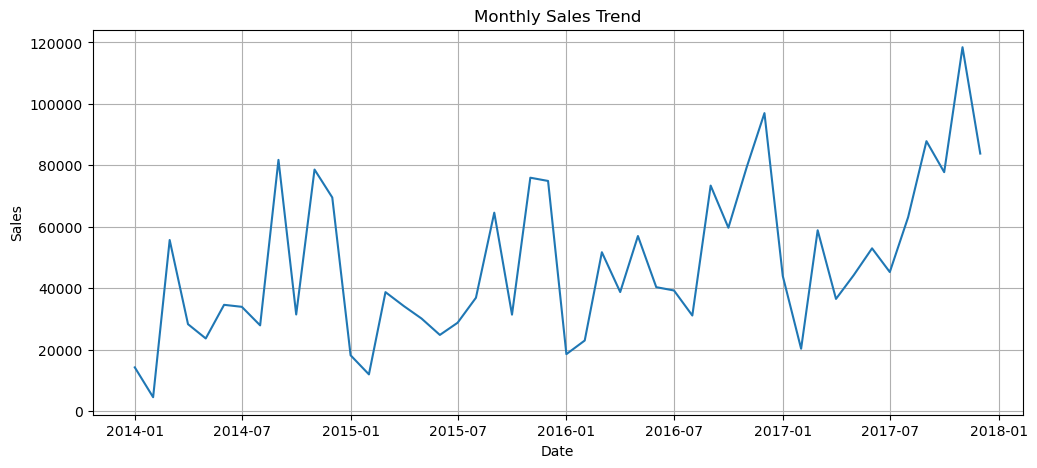

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## 5. Exploratory Data Analysis

The sales data is analyzed at yearly and monthly levels to identify overall trends and recurring seasonal patterns.

### Yearly Sales Analysis

Annual sales are calculated to understand the overall sales trend across the available years.

In [22]:
yearly_sales = df.groupby(
    df['Order Date'].dt.year
)['Sales'].sum()

yearly_sales

Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

### Monthly Sales Pattern

Sales are grouped by calendar month to identify recurring monthly patterns and seasonality.

In [23]:
monthly_pattern = df.groupby(
    df['Order Date'].dt.month
)['Sales'].sum()

monthly_pattern


Order Date
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

### Seasonal Sales Analysis

Average sales for each calendar month are calculated from the monthly time series to identify seasonal variations in sales.

seasonal_avg = monthly_sales.groupby(
    monthly_sales.index.month
).mean()

seasonal_avg


## 6. Feature Engineering

Time-based and lag features are created from the monthly sales data to help the machine learning model capture trends, seasonality, and historical sales patterns.

### Prepare Forecasting Dataset

In [26]:
forecast_df = monthly_sales.reset_index()

forecast_df.columns = ['Date', 'Sales']

forecast_df.head()

,Date,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


In [ ]:
### Time-Based Features

Year, month, and quarter features are extracted from the date to capture time-based sales patterns.

In [27]:
forecast_df['Year'] = forecast_df['Date'].dt.year
forecast_df['Month'] = forecast_df['Date'].dt.month
forecast_df['Quarter'] = forecast_df['Date'].dt.quarter

forecast_df.head()

,Date,Sales,Year,Month,Quarter
0,2014-01-01,14236.895,2014,1,1
1,2014-02-01,4519.892,2014,2,1
2,2014-03-01,55691.009,2014,3,1
3,2014-04-01,28295.345,2014,4,2
4,2014-05-01,23648.287,2014,5,2


### Time Index

A sequential time index is created to represent the progression of time in the monthly sales series.

In [28]:
forecast_df['TimeIndex'] = range(len(forecast_df))

forecast_df.head()

,Date,Sales,Year,Month,Quarter,TimeIndex
0,2014-01-01,14236.895,2014,1,1,0
1,2014-02-01,4519.892,2014,2,1,1
2,2014-03-01,55691.009,2014,3,1,2
3,2014-04-01,28295.345,2014,4,2,3
4,2014-05-01,23648.287,2014,5,2,4


### Lag Features

Lag features are created to provide the model with historical sales information.

- `Lag_1` represents sales from the previous month.
- `Lag_12` represents sales from the same month in the previous year.

In [29]:
forecast_df['Lag_1'] = forecast_df['Sales'].shift(1)
forecast_df['Lag_12'] = forecast_df['Sales'].shift(12)

forecast_df.head(15)

,Date,Sales,Year,Month,Quarter,TimeIndex,Lag_1,Lag_12
0,2014-01-01,14236.8950,2014,1,1,0,NaN,NaN
1,2014-02-01,4519.8920,2014,2,1,1,14236.8950,NaN
2,2014-03-01,55691.0090,2014,3,1,2,4519.8920,NaN
3,2014-04-01,28295.3450,2014,4,2,3,55691.0090,NaN
4,2014-05-01,23648.2870,2014,5,2,4,28295.3450,NaN
5,2014-06-01,34595.1276,2014,6,2,5,23648.2870,NaN
6,2014-07-01,33946.3930,2014,7,3,6,34595.1276,NaN
7,2014-08-01,27909.4685,2014,8,3,7,33946.3930,NaN
8,2014-09-01,81777.3508,2014,9,3,8,27909.4685,NaN
9,2014-10-01,31453.3930,2014,10,4,9,81777.3508,NaN


## 7. Prepare Data for Modeling

Rows containing missing values created by the lag features are removed so that the dataset is ready for machine learning.

In [30]:
model_df = forecast_df.dropna().copy()

model_df.head()

,Date,Sales,Year,Month,Quarter,TimeIndex,Lag_1,Lag_12
12,2015-01-01,18174.0756,2015,1,1,12,69545.6205,14236.895
13,2015-02-01,11951.4110,2015,2,1,13,18174.0756,4519.892
14,2015-03-01,38726.2520,2015,3,1,14,11951.4110,55691.009
15,2015-04-01,34195.2085,2015,4,2,15,38726.2520,28295.345
16,2015-05-01,30131.6865,2015,5,2,16,34195.2085,23648.287


## 8. Train-Test Split

The data is divided chronologically into training and testing sets. The first 30 monthly observations are used for training, while the final 6 observations are reserved for testing.

In [32]:
train = model_df[model_df['Date'] < '2017-07-01'].copy()
test = model_df[model_df['Date'] >= '2017-07-01'].copy()

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 30
Testing data: 6


## 9. Random Forest Regression

The Random Forest Regression algorithm is used to predict monthly sales.

The model uses year, month, quarter, time index, previous-month sales (`Lag_1`), and previous-year sales (`Lag_12`) as input features.

In [34]:
from sklearn.ensemble import RandomForestRegressor

features = ['Year', 'Month', 'Quarter', 'TimeIndex', 'Lag_1', 'Lag_12']

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (30, 6)
X_test: (6, 6)


### Train the Random Forest Model

A Random Forest Regressor with 200 trees is trained using the selected features and training data.

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

## 10. Model Evaluation

The trained Random Forest model is used to predict sales for the test period. The predictions are then compared with the actual sales values using standard regression metrics.

In [36]:
y_pred = model.predict(X_test)



[43587.9718815 42243.4293025 76912.242843  61411.730381  85833.396832
 87316.610066 ]


### Evaluation Metrics

The model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Lower values indicate better prediction performance.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14329.204037666646
RMSE: 17806.176305006462


### Actual vs Predicted Sales

The actual and predicted sales values for the test period are compared to assess how closely the model follows the observed sales.

In [38]:
comparison = test[['Date', 'Sales']].copy()
comparison['Predicted_Sales'] = y_pred

comparison

,Date,Sales,Predicted_Sales
42,2017-07-01,45264.4160,43587.971882
43,2017-08-01,63120.8880,42243.429303
44,2017-09-01,87866.6520,76912.242843
45,2017-10-01,77776.9232,61411.730381
46,2017-11-01,118447.8250,85833.396832
47,2017-12-01,83829.3188,87316.610066


### Actual vs Predicted Sales Visualization

The actual and predicted sales values are plotted to visually assess the model's forecasting performance on the test data.

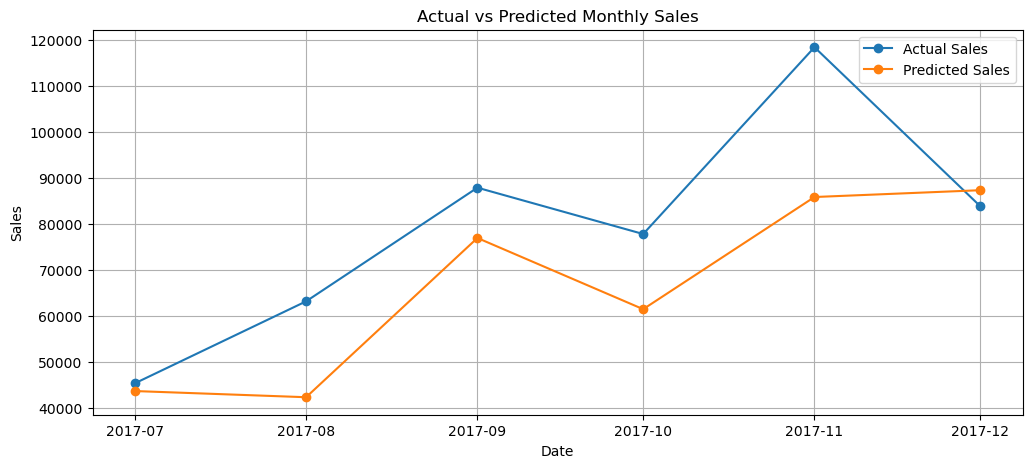

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(comparison['Date'], comparison['Sales'], marker='o', label='Actual Sales')
plt.plot(comparison['Date'], comparison['Predicted_Sales'], marker='o', label='Predicted Sales')

plt.title("Actual vs Predicted Sales — Test Period")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

### Mean Absolute Percentage Error (MAPE)

MAPE measures the average percentage difference between actual and predicted sales. Lower values indicate better forecasting performance.

In [40]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)

print("MAPE (%):", mape * 100)

MAPE: 0.16997023373300413
MAPE (%): 16.99702337330041


## 11. Feature Importance

The Random Forest model's feature importance scores are analyzed to identify which time-series features contribute most to the predictions.

In [41]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

Lag_12       0.559835
Month        0.218051
TimeIndex    0.119434
Lag_1        0.060171
Quarter      0.027121
Year         0.015388
dtype: float64

### Alternative Random Forest Model

A second Random Forest configuration is trained using 500 trees, a maximum depth of 8, and a minimum of 2 samples per leaf. Its performance is compared with the first model.

In [42]:
model2 = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)

model2.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred2 = model2.predict(X_test)

[43721.6380078  43358.27933967 74459.33336992 57600.27239532
 80421.02046258 80893.3154952 ]


### Evaluation of the Second Random Forest Model

The second Random Forest model is evaluated using MAE, RMSE, and MAPE and compared with the first model.

In [44]:
mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
mape2 = mean_absolute_percentage_error(y_test, y_pred2)

print("Model 2 MAE:", mae2)
print("Model 2 RMSE:", rmse2)
print("Model 2 MAPE (%):", mape2 * 100)

Model 2 MAE: 15975.360654919952
Model 2 RMSE: 20143.039634368364
Model 2 MAPE (%): 18.58742321124538


### Model Performance Comparison

The evaluation metrics of both Random Forest models are summarized to identify the better-performing model.

In [45]:
results = pd.DataFrame({
    'Model': ['Random Forest 1', 'Random Forest 2'],
    'MAE': [mae, mae2],
    'RMSE': [rmse, rmse2],
    'MAPE (%)': [mape * 100, mape2 * 100]
})

results

,Model,MAE,RMSE,MAPE (%)
0,Random Forest 1,14329.204038,17806.176305,16.997023
1,Random Forest 2,15975.360655,20143.039634,18.587423


## 12. Train Final Model

Random Forest 1 is selected as the final model because it achieved lower MAE, RMSE, and MAPE than Random Forest 2.

The selected model is retrained using the complete available modeling dataset before generating the 2018 forecast.

In [46]:
final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

final_model.fit(
    model_df[features],
    model_df['Sales']
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Generate 2018 Forecast Dates

Twelve monthly dates are generated for 2018 to produce the monthly sales forecast for the target year.

In [47]:
future_dates = pd.date_range(
    start='2018-01-01',
    periods=12,
    freq='MS'
)

future_dates

DatetimeIndex(['2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01',
               '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
               '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01'],
              dtype='datetime64[ns]', freq='MS')

## 13. Generate 2018 Forecast

The future dates for all 12 months of 2018 are created, along with the corresponding year, month, quarter, and time-index features required by the final Random Forest model.

In [48]:
future_df = pd.DataFrame({
    'Date': future_dates
})

future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Quarter'] = future_df['Date'].dt.quarter
future_df['TimeIndex'] = range(
    model_df['TimeIndex'].max() + 1,
    model_df['TimeIndex'].max() + 13
)

future_df

,Date,Year,Month,Quarter,TimeIndex
0,2018-01-01,2018,1,1,48
1,2018-02-01,2018,2,1,49
2,2018-03-01,2018,3,1,50
3,2018-04-01,2018,4,2,51
4,2018-05-01,2018,5,2,52
5,2018-06-01,2018,6,2,53
6,2018-07-01,2018,7,3,54
7,2018-08-01,2018,8,3,55
8,2018-09-01,2018,9,3,56
9,2018-10-01,2018,10,4,57


In [49]:
history = list(model_df['Sales'])

Last historical sales: 83829.3188


In [50]:
jan_2017_sales = model_df.loc[
    model_df['Date'] == '2017-01-01', 'Sales'
].iloc[0]


43971.374


In [51]:
jan_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 1,
    'Quarter': 1,
    'TimeIndex': 48,
    'Lag_1': 83829.3188,
    'Lag_12': 43971.374
}])

jan_prediction = final_model.predict(jan_features)[0]

print("Predicted January 2018 Sales:", jan_prediction)

Predicted January 2018 Sales: 48322.8677230001


In [52]:
feb_2017_sales = model_df.loc[
    model_df['Date'] == '2017-02-01', 'Sales'
].iloc[0]



20301.1334


In [53]:
feb_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 2,
    'Quarter': 1,
    'TimeIndex': 49,
    'Lag_1': jan_prediction,
    'Lag_12': feb_2017_sales
}])

feb_prediction = final_model.predict(feb_features)[0]

print("Predicted February 2018 Sales:", feb_prediction)


Predicted February 2018 Sales: 37999.75089599999


In [54]:
mar_2017_sales = model_df.loc[
    model_df['Date'] == '2017-03-01', 'Sales'
].iloc[0]



58872.3528


In [55]:
mar_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 3,
    'Quarter': 1,
    'TimeIndex': 50,
    'Lag_1': feb_prediction,
    'Lag_12': mar_2017_sales
}])

mar_prediction = final_model.predict(mar_features)[0]

print("Predicted March 2018 Sales:", mar_prediction)

Predicted March 2018 Sales: 72463.18254000007


In [56]:
apr_2017_sales = model_df.loc[
    model_df['Date'] == '2017-04-01', 'Sales'
].iloc[0]


36521.5361


In [57]:
apr_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 4,
    'Quarter': 2,
    'TimeIndex': 51,
    'Lag_1': mar_prediction,
    'Lag_12': apr_2017_sales
}])

apr_prediction = final_model.predict(apr_features)[0]

print("Predicted April 2018 Sales:", apr_prediction)

Predicted April 2018 Sales: 45924.57285350006


In [58]:
may_2017_sales = model_df.loc[
    model_df['Date'] == '2017-05-01', 'Sales'
].iloc[0]


44261.1102


In [59]:
may_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 5,
    'Quarter': 2,
    'TimeIndex': 52,
    'Lag_1': apr_prediction,
    'Lag_12': may_2017_sales
}])

may_prediction = final_model.predict(may_features)[0]

print("Predicted May 2018 Sales:", may_prediction)

Predicted May 2018 Sales: 51799.13946650011


In [60]:
jun_2017_sales = model_df.loc[
    model_df['Date'] == '2017-06-01', 'Sales'
].iloc[0]


52981.7257


In [61]:
jun_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 6,
    'Quarter': 2,
    'TimeIndex': 53,
    'Lag_1': may_prediction,
    'Lag_12': jun_2017_sales
}])

jun_prediction = final_model.predict(jun_features)[0]

print("Predicted June 2018 Sales:", jun_prediction)

Predicted June 2018 Sales: 51032.19203600009


In [62]:
jul_2017_sales = model_df.loc[
    model_df['Date'] == '2017-07-01', 'Sales'
].iloc[0]



45264.416


In [63]:
jul_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 7,
    'Quarter': 3,
    'TimeIndex': 54,
    'Lag_1': jun_prediction,
    'Lag_12': jul_2017_sales
}])

jul_prediction = final_model.predict(jul_features)[0]

print("Predicted July 2018 Sales:", jul_prediction)

Predicted July 2018 Sales: 50351.849527500075


In [64]:
aug_2017_sales = model_df.loc[
    model_df['Date'] == '2017-08-01', 'Sales'
].iloc[0]


63120.888


In [65]:
aug_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 8,
    'Quarter': 3,
    'TimeIndex': 55,
    'Lag_1': jul_prediction,
    'Lag_12': aug_2017_sales
}])

aug_prediction = final_model.predict(aug_features)[0]

print("Predicted August 2018 Sales:", aug_prediction)

Predicted August 2018 Sales: 83444.66183549995


In [66]:
sep_2017_sales = model_df.loc[
    model_df['Date'] == '2017-09-01', 'Sales'
].iloc[0]



87866.652


In [67]:
sep_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 9,
    'Quarter': 3,
    'TimeIndex': 56,
    'Lag_1': aug_prediction,
    'Lag_12': sep_2017_sales
}])

sep_prediction = final_model.predict(sep_features)[0]

print("Predicted September 2018 Sales:", sep_prediction)

Predicted September 2018 Sales: 99760.71130449978


In [68]:
oct_2017_sales = model_df.loc[
    model_df['Date'] == '2017-10-01', 'Sales'
].iloc[0]



77776.9232


In [69]:
oct_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 10,
    'Quarter': 4,
    'TimeIndex': 57,
    'Lag_1': sep_prediction,
    'Lag_12': oct_2017_sales
}])

oct_prediction = final_model.predict(oct_features)[0]

print("Predicted October 2018 Sales:", oct_prediction)

Predicted October 2018 Sales: 95302.71078399986


In [70]:
nov_2017_sales = model_df.loc[
    model_df['Date'] == '2017-11-01', 'Sales'
].iloc[0]



118447.825


In [71]:
nov_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 11,
    'Quarter': 4,
    'TimeIndex': 58,
    'Lag_1': oct_prediction,
    'Lag_12': nov_2017_sales
}])

nov_prediction = final_model.predict(nov_features)[0]

print("Predicted November 2018 Sales:", nov_prediction)

Predicted November 2018 Sales: 97077.94722849982


In [72]:
dec_2017_sales = model_df.loc[
    model_df['Date'] == '2017-12-01', 'Sales'
].iloc[0]



83829.3188


In [73]:
dec_features = pd.DataFrame([{
    'Year': 2018,
    'Month': 12,
    'Quarter': 4,
    'TimeIndex': 59,
    'Lag_1': nov_prediction,
    'Lag_12': dec_2017_sales
}])

dec_prediction = final_model.predict(dec_features)[0]

print("Predicted December 2018 Sales:", dec_prediction)

Predicted December 2018 Sales: 97328.20136049978


In [74]:
forecast_2018 = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': [
        jan_prediction,
        feb_prediction,
        mar_prediction,
        apr_prediction,
        may_prediction,
        jun_prediction,
        jul_prediction,
        aug_prediction,
        sep_prediction,
        oct_prediction,
        nov_prediction,
        dec_prediction
    ]
})

forecast_2018

,Date,Predicted_Sales
0,2018-01-01,48322.867723
1,2018-02-01,37999.750896
2,2018-03-01,72463.182540
3,2018-04-01,45924.572854
4,2018-05-01,51799.139467
5,2018-06-01,51032.192036
6,2018-07-01,50351.849528
7,2018-08-01,83444.661835
8,2018-09-01,99760.711304
9,2018-10-01,95302.710784


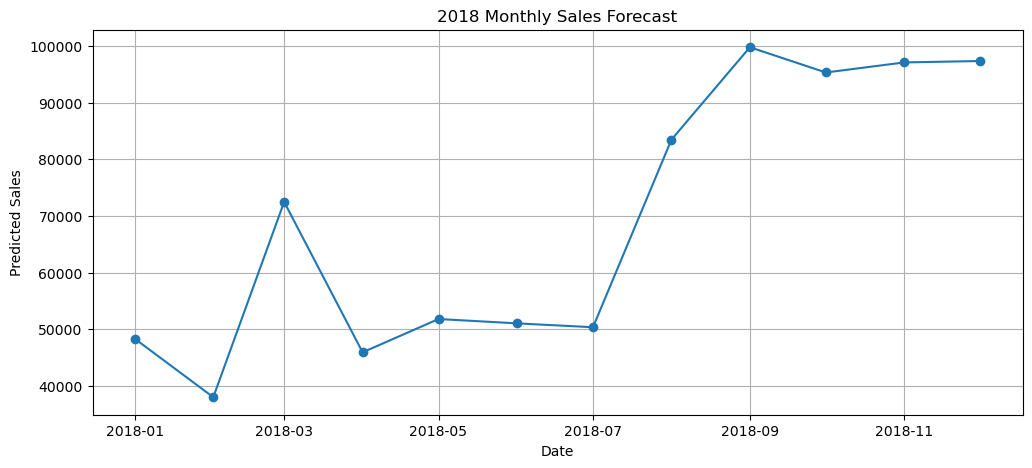

In [75]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_2018['Date'],
    forecast_2018['Predicted_Sales'],
    marker='o'
)

plt.title("2018 Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.show()

In [77]:

historical = forecast_df[['Date', 'Sales']].copy()
historical['Type'] = 'Actual'


future = forecast_2018[['Date', 'Predicted_Sales']].copy()
future.rename(columns={'Predicted_Sales': 'Sales'}, inplace=True)
future['Type'] = 'Forecast'


powerbi_data = pd.concat(
    [historical, future],
    ignore_index=True
)

powerbi_data.head()

,Date,Sales,Type
0,2014-01-01,14236.895,Actual
1,2014-02-01,4519.892,Actual
2,2014-03-01,55691.009,Actual
3,2014-04-01,28295.345,Actual
4,2014-05-01,23648.287,Actual


In [78]:
powerbi_data.to_csv(
    r"C:\Users\BHOOMIKA\OneDrive\Desktop\FUTURE_ML_01\dataset\powerbi_sales_forecast.csv",
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!
